<a href="https://colab.research.google.com/github/alexklupsch/alexklupsch.github.io/blob/main/multi_label_resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi Label Image Classification -- UCM airborne images -- Resnet

This notebook goes through our first attempt at handling the problem of a multi label classification of airborne images.

Inputs are 2100 images of the size 256x256p with a resolution of 0.3m, labeled by hand with 17 land cover classes. It is a relabeling of the original UCM dataset which consisted of a 100 images per single label class for 21 classes.

## 1. Adding Dependencies

In [1]:
!pip install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 65.5 MB/s eta 0:00:00


In [2]:
# basic modules
import os
import zipfile
import random

# plotting
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

# data wrangling
import pandas as pd

# pytorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.models as models
from torchvision.transforms import v2
from torchmetrics.classification import MultilabelF1Score, MultilabelHammingDistance

# lightning
import lightning as L
from lightning.pytorch import LightningModule, Trainer
from lightning.pytorch.callbacks import BackboneFinetuning
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

## 2. Data Loading

In [3]:
## loading the data and directory handling
! git clone https://git.wur.nl/lobry001/ucmdata.git
os.chdir('ucmdata')

with zipfile.ZipFile('UCMerced_LandUse.zip', 'r') as zip_ref:
  zip_ref.extractall('UCMImages')

!mv UCMImages/UCMerced_LandUse/Images .
!rm -rf UCMImages README.md UCMerced_LandUse.zip
!ls

UCM_images_path = "Images/"
Multilabels_path = "LandUse_Multilabeled.txt"

Cloning into 'ucmdata'...
remote: Enumerating objects: 8, done.
remote: Total 8 (delta 0), reused 0 (delta 0), pack-reused 8 (from 1)
Receiving objects: 100% (8/8), 316.99 MiB | 16.39 MiB/s, done.
Images	LandUse_Multilabeled.txt


In [4]:
# loading the labels
path = "/content/ucmdata/LandUse_Multilabeled.txt"
df = pd.read_csv(path, sep="\t", header=0)
df.head()

,IMAGE\LABEL,airplane,bare-soil,buildings,cars,chaparral,court,dock,field,grass,mobile-home,pavement,sand,sea,ship,tanks,trees,water
0,agricultural00,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
1,agricultural01,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,agricultural02,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,agricultural03,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,agricultural04,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


<Axes: xlabel='Count', ylabel='class'>

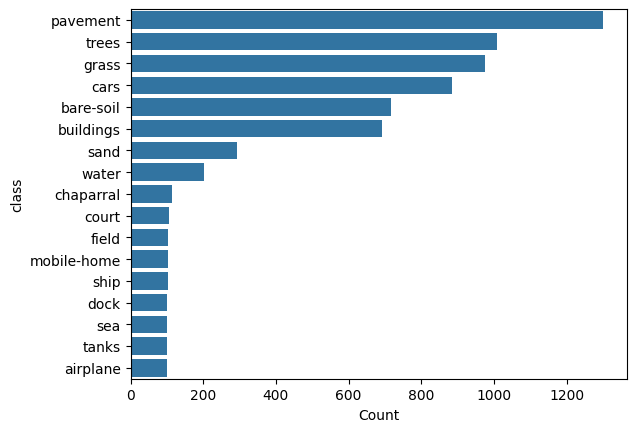

In [5]:
# calc and plot the class count -> adjusted from medium post
class_count = pd.DataFrame(df.sum(axis=0)).reset_index()
class_count.columns = ["class", "Count"]
class_count.drop(class_count.index[0], inplace=True)
class_count = class_count.sort_values(by="Count", ascending=False)

sns.barplot(class_count, x="Count", y="class")


In [6]:
## Accessing the images
dir = "/content/ucmdata/Images"
image_dict = {} # dict for key:class, value: [image_paths]
labels_map = {} # dict for key:class_num, value: class_name

for class_num, class_name in enumerate(os.listdir(dir)):
  labels_map[class_num] = class_name
  class_dir = os.path.join(dir, class_name)

  if os.path.isdir(class_dir): # sort out *.txt-file
    for image in os.listdir(class_dir):
      image_path = os.path.join(class_dir, image)
      df.loc[df["IMAGE\\LABEL"] == image.split(sep=".")[0], ["path"]] = image_path # string matching, then save path in column

In [7]:
print(df["path"].notna().all())
df.head()

True


,IMAGE\LABEL,airplane,bare-soil,buildings,cars,chaparral,court,dock,field,grass,mobile-home,pavement,sand,sea,ship,tanks,trees,water,path
0,agricultural00,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,/content/ucmdata/Images/agricultural/agricultu...
1,agricultural01,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,/content/ucmdata/Images/agricultural/agricultu...
2,agricultural02,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,/content/ucmdata/Images/agricultural/agricultu...
3,agricultural03,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,/content/ucmdata/Images/agricultural/agricultu...
4,agricultural04,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,/content/ucmdata/Images/agricultural/agricultu...


In [8]:
# reduce dataset to one hot encoding vectors
label_cols = df.columns.difference(["IMAGE\\LABEL", "path"])

# transfrom
labels = df[label_cols].values
paths = df["path"].values
dataset = [(path, label) for label, path in zip(labels, paths)]

## 3. Training, Validation and Test Split

In [11]:
def split_train_test(dataset, val_ratio, test_ratio):
  """
  Split dataset into train, validation and test datasets.

  Args:
      dataset: A pandas dataframe with a sample per row
      val_ratio: The ratio of images to allocate for the validation set.
      test_ratio: The ratio of images to allocate for the test set.

  Returns:
      train_dataset, val_dataset, test_dataset: Lists of tuples (image_path, label_vector)
  """
  random.seed(42) # to ensure the same test set for different models
  train_dataset = []
  val_dataset = []
  test_dataset = []

  sample_length = len(dataset)
  test_split = int(sample_length * test_ratio)
  var_split = int(sample_length * val_ratio)

  random.shuffle(dataset)

  test_dataset.extend([sample for sample in dataset[:test_split]])
  dataset = dataset[test_split:]

  val_dataset.extend([sample for sample in dataset[:var_split]])
  train_dataset.extend([sample for sample in dataset[var_split:]])

  return train_dataset, val_dataset, test_dataset

train_dataset,val_dataset, test_dataset = split_train_test(dataset, val_ratio = 0.15, test_ratio=0.15)

In [12]:
def plot_random_samples(data, n_samples=20, cols=5, figsize=(15, 3)):
    """
    Plot random images from dataset (ignores labels).

    Parameters
    ----------
    data : list of tuples
        Each item is (image_path, label_vector)
    n_samples : int
        Number of random images to plot
    cols : int
        Number of subplot columns
    figsize : tuple
        Base figure size (width, height_per_row)
    """

    # Randomly sample data points
    samples = random.sample(data, min(n_samples, len(data)))

    rows = (len(samples) + cols - 1) // cols
    plt.figure(figsize=(figsize[0], figsize[1] * rows))

    for i, (image_path, label_vector) in enumerate(samples):
        with Image.open(image_path) as img:
            img = img.convert("RGB")

            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)

            active_labels = [label_cols[j] for j, v in enumerate(label_vector) if v == 1]
            plt.title(", ".join(active_labels), fontsize=8)

            plt.axis("off")

    plt.tight_layout()
    plt.show()

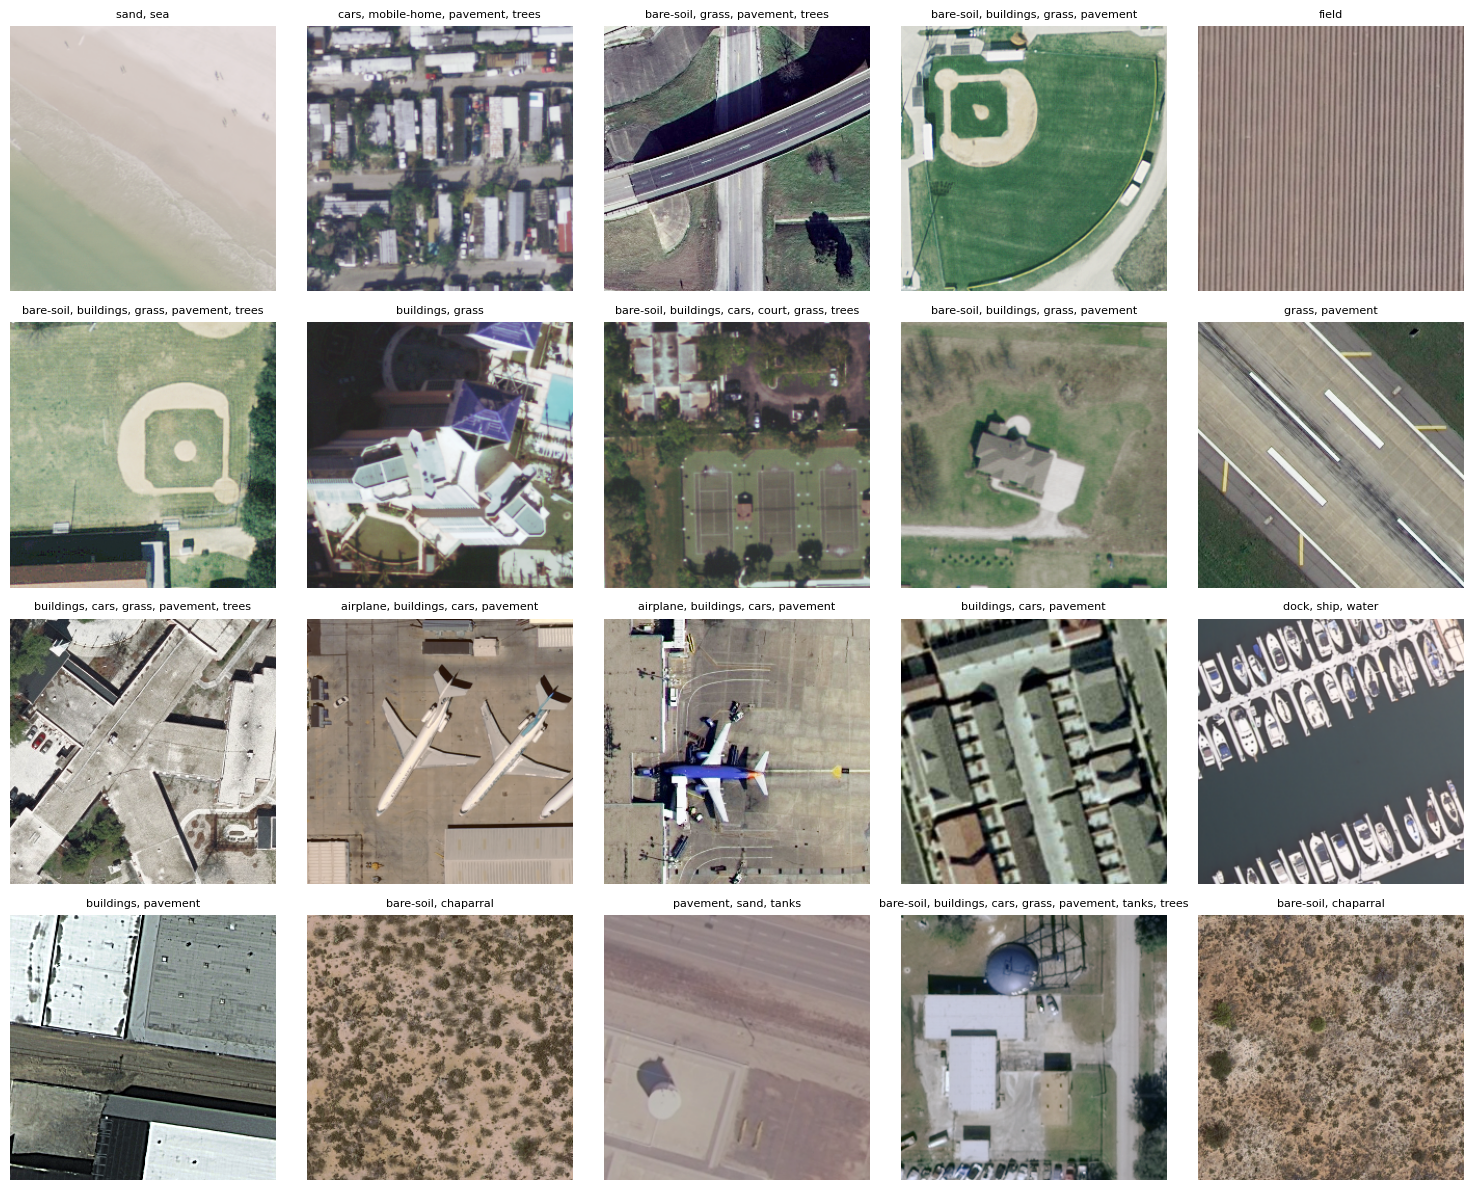

In [13]:
plot_random_samples(test_dataset)

## 4. Dataloader and Transformations

In [14]:
class UCMDatasetMultiLabel(Dataset):
  """
  Custom PyTorch Dataset class for UCM multi-label image classification.

  This dataset handles loading images from specified paths and applying
  transformations, along with providing their corresponding multi-hot encoded labels.
  """
  def __init__(self, samples_list, transform=None):
    """
    Initializes the UCMDatasetMultiLabel.
    """

    self.samples = samples_list
    self.transform = transform

  def __len__(self):
    """
    Returns the total number of samples in the dataset,
    used for bacthing and iteration.
    """
    return len(self.samples)

  def __getitem__(self, index):
    """
    Retrieves an image and its corresponding label by index.

    Args:
        index: The index of the sample to retrieve.

    Returns:
        A tuple containing the image and its label.
    """
    img_path = self.samples[index][0]
    image = Image.open(img_path)
    label = self.samples[index][1]
    if self.transform:
      image = self.transform(image)
    return image, label

In [15]:
transforms_aug = v2.Compose([
    v2.Resize((224, 224)), ## valid resnet image size, fix passing size as tuple
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=(-10, 10)),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean= [0.485, 0.456,0.406],
                 std=[0.229, 0.224, 0.225])  ## imagenet mean and std
])

transforms = v2.Compose([
        v2.Resize((224, 224)), ## valid resnet image size, fix passing size as tuple
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean= [0.485, 0.456,0.406],
                     std=[0.229, 0.224, 0.225])  ## imagenet mean and std
])


## define the transforms
def make_dataloaders(train_df, val_df, test_df, batch_size=32, augmentation=False):
    train_transform = transforms_aug if augmentation else transforms

    train_dataset = UCMDatasetMultiLabel(train_df, transform=train_transform)
    val_dataset = UCMDatasetMultiLabel(val_df, transform=transforms)
    test_dataset = UCMDatasetMultiLabel(test_df, transform=transforms)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [16]:
# Example of a loaded dataset for looking at plots

train_dataloader, val_dataloader, test_dataloader = make_dataloaders(
    train_df= train_dataset,
    val_df= val_dataset,
    test_df= test_dataset,
    batch_size=32,
    augmentation=True
)

Feature batch shape: torch.Size([32, 3, 224, 224])
Labels batch shape: torch.Size([32, 17])


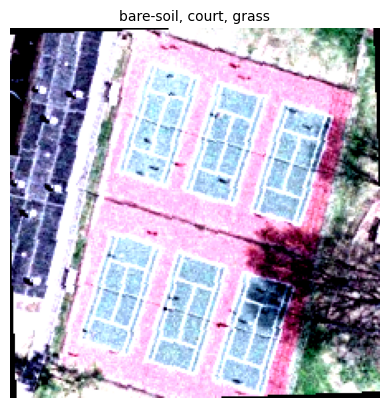

Raw label vector: tensor([0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])


In [19]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

img = train_features[0].squeeze()
label = train_labels[0]

### Unnormalize if wanted
# mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
# std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
# img = img * std + mean

img = torch.clamp(img, 0, 1)

# Convert label vector to class names
active_indices = (label == 1).nonzero(as_tuple=True)[0].tolist()
label_names = [label_cols[i] for i in active_indices]

# Plot
plt.imshow(img.permute(1, 2, 0))
plt.title(", ".join(label_names), fontsize=10)
plt.axis("off")
plt.show()

print(f"Raw label vector: {label}")

## 5. Model declaration

In [20]:
# setting up weights and biases
import wandb
wandb.login(relogin =True)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: alexander-klupsch (WURdeepleanring) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [21]:
class ResNetClassifier(LightningModule):
    def __init__(self, learning_rate, model, num_classes=17, freeze=True, dropout=True, threshold=0.5):
        super().__init__()
        self.save_hyperparameters()

        # Backbone from pretrained Resnet
        if model == "resnet18":
            resnet = models.resnet18(weights="DEFAULT")
        elif model =="resnet50":
            resnet = models.resnet50(weights="DEFAULT")
        # Remove final classification layer
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])

        # Freeze backbone
        if self.hparams.freeze:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # custom dropout for dropout or without
        if dropout:
            self.head = nn.Sequential(
                nn.Flatten(),
                nn.Linear(resnet.fc.in_features, 512),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(512, num_classes)
            )
        else:
          self.head = nn.Sequential(
              nn.Flatten(),
              nn.Linear(resnet.fc.in_features, 512),
              nn.ReLU(),
              nn.Linear(512, num_classes)
          )

        # define accuracy metrics for training, validation and test
        # -> state-based so indivual metrics for all steps
        self.train_f1_macro = MultilabelF1Score(num_labels=num_classes, average='macro')
        self.train_f1_micro = MultilabelF1Score(num_labels=num_classes, average='micro')
        self.train_hamming = MultilabelHammingDistance(num_labels=num_classes)

        self.val_f1_macro = MultilabelF1Score(num_labels=num_classes, average='macro')
        self.val_f1_micro = MultilabelF1Score(num_labels=num_classes, average='micro')
        self.val_hamming = MultilabelHammingDistance(num_labels=num_classes)

        self.test_f1_macro = MultilabelF1Score(num_labels=num_classes, average='macro')
        self.test_f1_micro = MultilabelF1Score(num_labels=num_classes, average='micro')
        self.test_hamming = MultilabelHammingDistance(num_labels=num_classes)

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)  # raw logits


    def training_step(self, batch, batch_idx):
        x, y = batch
        y = y.float() # important for BCEWithLogitsLoss
        logits = self(x)

        # Multi label loss
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y)
        # convert logits to probs
        probs = torch.sigmoid(logits)
        # convert to binary predictions
        preds = (probs >= self.hparams.threshold).float()
        # update metrics
        f1_macro = self.train_f1_macro(preds, y.int())
        f1_micro = self.train_f1_micro(preds, y.int())
        hamming = self.train_hamming(preds, y.int())

        self.log('train_loss', loss)
        self.log('train_f1_macro', f1_macro)
        self.log('train_f1_micro', f1_micro)
        self.log('train_hamming', hamming)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y = y.float()
        logits = self(x)

        loss = nn.functional.binary_cross_entropy_with_logits(logits, y)
        probs = torch.sigmoid(logits)
        preds = (probs >= self.hparams.threshold).float()
        f1_macro = self.val_f1_macro(preds, y.int())
        f1_micro = self.val_f1_micro(preds, y.int())
        hamming = self.val_hamming(preds, y.int())

        self.log('val_loss', loss)
        self.log('val_f1_macro', f1_macro)
        self.log('val_f1_micro', f1_micro)
        self.log('val_hamming', hamming)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y = y.float()
        logits = self(x)

        loss = nn.functional.binary_cross_entropy_with_logits(logits, y)
        probs = torch.sigmoid(logits)
        preds = (probs >= self.hparams.threshold).float()
        f1_macro= self.test_f1_macro(preds, y.int())
        f1_micro = self.test_f1_micro(preds, y.int())
        hamming = self.test_hamming(preds, y.int())

        self.log('test_loss', loss)
        self.log('test_f1_macro', f1_macro)
        self.log('test_f1_micro', f1_micro)
        self.log('test_hamming', hamming)
        return loss

    def predict_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        probs = torch.sigmoid(logits)
        preds = (probs >= self.hparams.threshold).int()
        return preds, probs, y

    def configure_optimizers(self):
        params_optimize = [p for p in self.parameters() if p.requires_grad]
        optimizer = torch.optim.Adam(params_optimize, lr=self.hparams.learning_rate)
        return optimizer


## 6. Training Runs

In [22]:
'''
chosen training parameters
    "models": ["resnet18", "resnet50"],
    "learning_rates": [1e-3, 3e-4],
    "freeze": [True, False],
    "dropout": [True, False],
    "epochs": 10,
    "augmentation": [True, False],
    "early_stopping": [True, False]
'''

experiments = [
    {
        "run_name": "resnet18_baseline",
        "model": "resnet18",
        "learning_rate": 1e-3,
        "freeze": False,
        "dropout": False,
        "augmentation": False,
        "early_stopping": False,
        "epochs": 10
    },
    {
        "run_name": "resnet18_dropout_only",
        "model": "resnet18",
        "learning_rate": 1e-3,
        "freeze": False,
        "dropout": True,
        "augmentation": False,
        "early_stopping": False,
        "epochs": 10
    },
    {
        "run_name": "resnet18_augmentation_only",
        "model": "resnet18",
        "learning_rate": 1e-3,
        "freeze": False,
        "dropout": False,
        "augmentation": True,
        "early_stopping": False,
        "epochs": 10
    },
    {
        "run_name": "resnet18_freeze_only",
        "model": "resnet18",
        "learning_rate": 1e-3,
        "freeze": True,
        "dropout": False,
        "augmentation": False,
        "early_stopping": False,
        "epochs": 10
    },
    {
        "run_name": "resnet18_earlystop_only",
        "model": "resnet18",
        "learning_rate": 1e-3,
        "freeze": False,
        "dropout": False,
        "augmentation": False,
        "early_stopping": True,
        "epochs": 10
    },
    {
        "run_name": "resnet18_learning_rate_3e-4",
        "model": "resnet18",
        "learning_rate": 3e-4,
        "freeze": False,
        "dropout": False,
        "augmentation": False,
        "early_stopping": False,
        "epochs": 10
    },
    {
        "run_name": "resnet18_all_adjustments_freeze",
        "model": "resnet18",
        "learning_rate": 3e-4,
        "freeze": True,
        "dropout": True,
        "augmentation": True,
        "early_stopping": True,
        "epochs": 10
    },
    {
        "run_name": "resnet18_all_adjustments_unfreeze",
        "model": "resnet18",
        "learning_rate": 3e-4,
        "freeze": False,
        "dropout": True,
        "augmentation": True,
        "early_stopping": True,
        "epochs": 10
    },

    {
        "run_name": "resnet50_baseline",
        "model": "resnet50",
        "learning_rate": 1e-3,
        "freeze": False,
        "dropout": False,
        "augmentation": False,
        "early_stopping": False,
        "epochs": 10
    },
    {
        "run_name": "resnet50_dropout_only",
        "model": "resnet50",
        "learning_rate": 1e-3,
        "freeze": False,
        "dropout": True,
        "augmentation": False,
        "early_stopping": False,
        "epochs": 10
    },
    {
        "run_name": "resnet50_augmentation_only",
        "model": "resnet50",
        "learning_rate": 1e-3,
        "freeze": False,
        "dropout": False,
        "augmentation": True,
        "early_stopping": False,
        "epochs": 10
    },
    {
        "run_name": "resnet50_freeze_only",
        "model": "resnet50",
        "learning_rate": 1e-3,
        "freeze": True,
        "dropout": False,
        "augmentation": False,
        "early_stopping": False,
        "epochs": 10
    },
    {
        "run_name": "resnet50_earlystop_only",
        "model": "resnet50",
        "learning_rate": 1e-3,
        "freeze": False,
        "dropout": False,
        "augmentation": False,
        "early_stopping": True,
        "epochs": 10
    },
    {
        "run_name": "resnet50_learning_rate_3e-4",
        "model": "resnet50",
        "learning_rate": 3e-4,
        "freeze": False,
        "dropout": False,
        "augmentation": False,
        "early_stopping": False,
        "epochs": 10
    },
    {
        "run_name": "resnet50_all_adjustments_freeze",
        "model": "resnet50",
        "learning_rate": 3e-4,
        "freeze": True,
        "dropout": True,
        "augmentation": True,
        "early_stopping": True,
        "epochs": 10
    },
    {
        "run_name": "resnet50_all_adjustments_unfreeze",
        "model": "resnet50",
        "learning_rate": 3e-4,
        "freeze": False,
        "dropout": True,
        "augmentation": True,
        "early_stopping": True,
        "epochs": 10
    },
        {
        "run_name": "resnet50_all_adjustments_freeze_epochs",
        "model": "resnet50",
        "learning_rate": 3e-4,
        "freeze": True,
        "dropout": True,
        "augmentation": True,
        "early_stopping": True,
        "epochs": 20
    },
    {
        "run_name": "resnet50_all_adjustments_unfreeze_epochs",
        "model": "resnet50",
        "learning_rate": 3e-4,
        "freeze": False,
        "dropout": True,
        "augmentation": True,
        "early_stopping": True,
        "epochs": 20
    }
]

In [ ]:
results = []

for exp in experiments:

    L.seed_everything(42, workers=True)
    print(f"\nStarting run: {exp['run_name']}")

    # Make sure previous run is closed
    if wandb.run is not None:
        wandb.finish()

    # Create a new W&B logger
    wandb_logger = WandbLogger(
        project="multi_label_" + exp["model"],
        name=exp["run_name"]
    )

    # Log config to W&B
    wandb_logger.experiment.config.update({
        "dataset": "UCM multi label",
        "model": exp["model"],
        "learning_rate": exp["learning_rate"],
        "freeze": exp["freeze"],
        "dropout": exp["dropout"],
        "augmentation": exp["augmentation"],
        "early_stopping": exp["early_stopping"],
        "epochs": exp["epochs"]
    })

    # Create dataloaders
    train_loader, val_loader, test_loader = make_dataloaders(
        train_df= train_dataset,
        val_df= val_dataset,
        test_df= test_dataset,
        batch_size=32,
        augmentation=exp["augmentation"]
    )

    # Create model
    model = ResNetClassifier(
        learning_rate=exp["learning_rate"],
        model=exp["model"],
        num_classes=17,
        freeze=exp["freeze"],
        dropout=exp["dropout"]
    )

    # Callbacks
    callbacks = []
    if exp["early_stopping"]:
        callbacks.append(
            EarlyStopping(
                monitor="val_loss",
                patience=3,
                mode="min"
            )
        )

    # Trainer
    trainer = Trainer(
        max_epochs=exp["epochs"],
        logger=wandb_logger,
        callbacks=callbacks,
    )

    # Train
    trainer.fit(model, train_loader, val_loader)

    # Validate
    val_metrics = trainer.validate(model, dataloaders=val_loader, verbose=False)

    results.append({
        "run_name": exp["run_name"],
        "val_metrics": val_metrics,
    })

    wandb.finish()

## 7. Best performing Models

In [ ]:
# use seafile for confusion matrix
#trainer.test(dataloaders=test_dataloader)
preds = trainer.predict(model, val_dataloader)

all_preds = torch.cat([p[0] for p in preds])
all_targets = torch.cat([p[2] for p in preds])

# Convert logits → probabilities → binary predictions
y_pred = all_preds.int()
y_true = all_targets.int()

In [ ]:
preds[0]

In [ ]:
print(next(iter(zip(all_preds, all_targets.int()))))

In [ ]:
for i, class_name in enumerate(label_cols):
    y_t = y_true[:, i]
    y_p = y_pred[:, i]

    TP = ((y_p == 1) & (y_t == 1)).sum().item()
    TN = ((y_p == 0) & (y_t == 0)).sum().item()
    FP = ((y_p == 1) & (y_t == 0)).sum().item()
    FN = ((y_p == 0) & (y_t == 1)).sum().item()

    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-8)
    recall = TP / (TP + FN + 1e-8)   # how many positives you found
    precision = TP / (TP + FP + 1e-8)

    print(f"\nClass: {class_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

In [ ]:


# =========================
# Overall metrics
# =========================

# Element-wise accuracy
overall_accuracy = (y_pred == y_true).float().mean().item()

# Subset (exact match) accuracy
subset_accuracy = (y_pred == y_true).all(dim=1).float().mean().item()

print(f"Overall element-wise accuracy: {overall_accuracy:.4f}")
print(f"Subset accuracy (exact match): {subset_accuracy:.4f}")

# =========================
# Per-class accuracy
# =========================

per_class_accuracy = (y_pred == y_true).float().mean(dim=0)

print("\nPer-class accuracy:")
for i, class_name in enumerate(label_cols):
    print(f"{class_name}: {per_class_accuracy[i].item():.4f}")

# =========================
# Optional: better metrics (recommended)
# =========================

from sklearn.metrics import classification_report

print("\nClassification report:")
print(classification_report(
    y_true.numpy(),
    y_pred.numpy(),
    target_names=label_cols,
    zero_division=0
))

In [ ]:
def plot_mismatches(
    model,
    dataloader,
    label_cols,
    device,
    threshold=0.5,
    max_images=12,
    cols=3,
    figsize=(15, 5),
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
):
    """
    Plot misclassified multi-label samples with true and predicted labels.

    Parameters
    ----------
    model : torch.nn.Module
        Trained model.
    dataloader : torch.utils.data.DataLoader
        Dataloader yielding (images, labels).
    label_cols : list-like
        Class names in the same order as the multi-hot label vectors.
    device : torch.device or str
        Device used for inference.
    threshold : float
        Sigmoid threshold for turning probabilities into binary predictions.
    max_images : int
        Maximum number of mismatched images to display.
    cols : int
        Number of subplot columns.
    figsize : tuple
        Base figure size (width, height_per_row).
    mean, std : tuple
        Normalization stats used for unnormalizing images before plotting.
    """
    import math
    import torch
    import matplotlib.pyplot as plt

    model.eval()
    model.to(device)

    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)

    mismatches = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).int()

            # Find samples where full label vector does not match
            mismatch_mask = ~(preds == y.int()).all(dim=1)
            mismatch_indices = mismatch_mask.nonzero(as_tuple=True)[0]

            for idx in mismatch_indices:
                mismatches.append((
                    x[idx].cpu(),
                    y[idx].cpu().int(),
                    preds[idx].cpu().int()
                ))

                if len(mismatches) >= max_images:
                    break

            if len(mismatches) >= max_images:
                break

    if len(mismatches) == 0:
        print("No mismatches found.")
        return

    rows = math.ceil(len(mismatches) / cols)
    plt.figure(figsize=(figsize[0], figsize[1] * rows))

    for i, (img, y_true, y_pred) in enumerate(mismatches):
        # Unnormalize image
        img = img * std + mean
        img = torch.clamp(img, 0, 1)

        # Convert label vectors to names
        true_names = [label_cols[j] for j, v in enumerate(y_true) if v == 1]
        pred_names = [label_cols[j] for j, v in enumerate(y_pred) if v == 1]

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img.permute(1, 2, 0))
        plt.axis("off")
        plt.title(
            "True: " + (", ".join(true_names) if true_names else "none") +
            "\nPred: " + (", ".join(pred_names) if pred_names else "none"),
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

In [ ]:
plot_mismatches(
    model,
    val_dataloader,
    label_cols=label_cols,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    threshold=0.5,
    max_images=12
)